# Retail sales analytics & customer segmentation

This project analyzes retail transaction data to uncover customer purchasing patterns and build actionable business insights using Python, MySQL, and Power BI.


## Business problem

UK retail stores face increasing competition, rising operating costs, and changing customer shopping behavior.
To remain competitive, retailers must move beyond intuition-based decisions and leverage data to understand how customers interact with their business.

Many retailers lack clear visibility into customer value and purchasing behavior, making it difficult to design effective marketing strategies and improve customer retention.
This project demonstrates how data analytics and machine learning can be used to transform raw transaction data into actionable business insights.


## Project objective

The objective of this project is to analyze retail transaction data to:
- Understand customer spending behavior
- Identify distinct customer segments
- Provide data-driven insights for marketing and sales decisions


## Key business questions

1. Who are the highest-value customers?
2. How frequently do customers make purchases?
3. Can customers be grouped based on spending behavior?
4. Which customer segments generate the most revenue?


## Tools & technologies

- Python (Jupyter Notebook): Data cleaning, analysis, and modeling
- Pandas & NumPy: Data manipulation and calculations
- Scikit-learn: Customer segmentation using clustering
- MySQL: Retail data storage and querying
- Power BI: Interactive dashboards and business reporting
- GitHub: Version control and portfolio presentation


## Dataset description

The dataset contains retail transaction records with:
- Customer ID
- Transaction amount
- Transaction date

The data represents customer purchasing activity over time.

#### Why this matters:
Understanding data structure is critical before analysis begins.


## Analytical approach

1. Data exploration and quality checks
2. Data cleaning
3. Feature engineering to summarize customer behavior
4. Customer segmentation using machine learning
5. Exporting results for visualization in Power BI

#### Why this matters:
A structured approach ensures accuracy and reproducibility.


## Expected business value

This analysis can helps UK retailers:

- Target high-value customers
- Personalize marketing campaigns
- Improve customer retention
- Make data-driven sales decisions


#### Why this matters:
Business owners/decision makers, care about impact, not just code.


## Step 1: Import libraries

##### I will import libraries for data manipulation, visualization, database access, and machine learning.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


Run the above cell.

## Step 2: Generate sample retail transaction data

I will create a sample dataset to simulate real retail transactions for this analysis.

##### Why I will use synthetic Data

While there are retail datasets available on platforms like Kaggle, most real-world retail transaction data is **sensitive and cannot be publicly shared** due to privacy and GDPR regulations in the UK. 

###### Using synthetic data allows me to:

- Demonstrate **full data analytics workflows** without violating privacy
- Generate **controlled scenarios** that match business questions
- Ensure the dataset contains **key features needed for analysis and modeling**
- Maintain **reproducibility**, so anyone can run the notebook and replicate results



In [3]:
import pandas as pd
import numpy as np
import os

# 1. Set random seed for reproducibility
np.random.seed(42)

# 2. Generate synthetic retail transaction data
data = {
    "customer_id": np.random.randint(1, 201, 1000),
    "amount": np.random.uniform(5, 500, 1000),
    "transaction_date": pd.date_range(start="2023-01-01", periods=1000, freq="D")
}

# 3. Create DataFrame
df = pd.DataFrame(data)

# 4. Save to Downloads folder
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", "synthetic_retail_data.csv")
df.to_csv(downloads_path, index=False)

print(f"Dataset saved successfully to: {downloads_path}")


Dataset saved successfully to: C:\Users\ASUS-PC\Downloads\synthetic_retail_data.csv


## Step 2: Load the data

##### I loaded the synthetic retail dataset to begin analysis and ensure it is readable in Python.


In [10]:
# Load the dataset (from Downloads or project data folder)
df = pd.read_csv(r"C:\Users\ASUS-PC\Downloads\synthetic_retail_data.csv")

# Show first 5 rows
df.head()


,customer_id,amount,transaction_date
0,103,295.335040,2023-01-01
1,180,284.406979,2023-01-02
2,93,192.492450,2023-01-03
3,15,172.036183,2023-01-04
4,107,450.325462,2023-01-05


## Step 3: Data cleaning

##### I checked for missing values to ensure the dataset is complete and ready for analysis.

#### Why this matters:
##### Even synthetic data can have gaps in real scenarios; cleaning ensures analysis won’t break.


In [11]:
# Check for missing values
df.isnull().sum()


customer_id         0
amount              0
transaction_date    0
dtype: int64

## Step 4: Check data types

##### I have to confirm columns have correct types for calculations and modeling.


In [12]:
df.dtypes


customer_id           int64
amount              float64
transaction_date     object
dtype: object

## Step 5: Correct Data Types

##### I have to convert columns to appropriate types so that calculations and date operations work correctly.


In [13]:
# Convert transaction_date to datetime if not already
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Check again
df.dtypes


customer_id                  int64
amount                     float64
transaction_date    datetime64[ns]
dtype: object

## Step 6: Check for duplicate rows

##### I have to ensure there are no duplicate transactions that could bias the analysis.
 
#### Why this matters:

##### Duplicate transactions can skew totals, averages, and clustering results.

In [14]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# Remove duplicates if any
df = df.drop_duplicates()


Number of duplicate rows: 0


In [ ]:
## Step 7: Check for outliers

I inspected numeric columns for extreme values that could distort analysis.


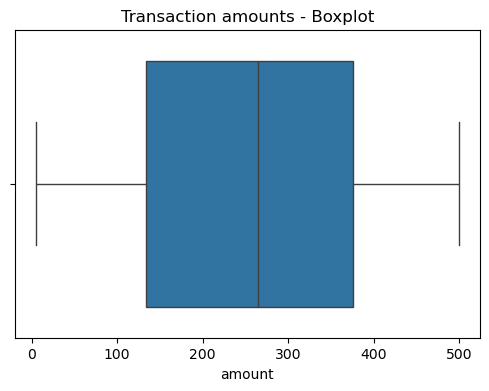

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot for transaction amounts
plt.figure(figsize=(6,4))
sns.boxplot(x=df['amount'])
plt.title("Transaction amounts - Boxplot")
plt.show()


## Step 8: Handle outliers (Optional)

##### We cap extreme values to reduce their impact on analysis.

#### Why this matters:
##### Outliers can affect clustering, averages, and visualizations; handling them improves model stability.


In [17]:
# Cap amounts at 1st and 99th percentile
lower = df['amount'].quantile(0.01)
upper = df['amount'].quantile(0.99)
df['amount'] = df['amount'].clip(lower, upper)

# Quick check
df.describe()


,customer_id,amount,transaction_date
count,1000.000000,1000.000000,1000
mean,101.697000,256.613333,2024-05-14 12:00:00
min,1.000000,7.546548,2023-01-01 00:00:00
25%,51.750000,133.660741,2023-09-07 18:00:00
50%,104.000000,264.408766,2024-05-14 12:00:00
75%,150.250000,376.000872,2025-01-19 06:00:00
max,200.000000,495.124400,2025-09-26 00:00:00
std,57.629249,140.597239,NaN


## Step 9: Exploratory Data Analysis (EDA)

##### I want to explore the dataset to understand structure, distributions, and potential issues if there could still be some issues after cleanibg.


In [18]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       1000 non-null   int64         
 1   amount            1000 non-null   float64       
 2   transaction_date  1000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 23.6 KB


,customer_id,amount,transaction_date
count,1000.000000,1000.000000,1000
mean,101.697000,256.613333,2024-05-14 12:00:00
min,1.000000,7.546548,2023-01-01 00:00:00
25%,51.750000,133.660741,2023-09-07 18:00:00
50%,104.000000,264.408766,2024-05-14 12:00:00
75%,150.250000,376.000872,2025-01-19 06:00:00
max,200.000000,495.124400,2025-09-26 00:00:00
std,57.629249,140.597239,NaN


## Step 10: Feature engineering

##### I created features that summarize customer spending behavior.


In [19]:
customer_summary = df.groupby("customer_id").agg(
    total_spend=("amount", "sum"),
    transaction_count=("amount", "count"),
    avg_spend=("amount", "mean")
).reset_index()

customer_summary.head()


,customer_id,total_spend,transaction_count,avg_spend
0,1,2452.515228,8,306.564404
1,2,1736.896618,5,347.379324
2,3,1773.132274,6,295.522046
3,4,836.761564,4,209.190391
4,5,1493.776680,6,248.962780


## Step 11: Customer segmentation

##### I applied clustering to group customers based on spending patterns.


In [20]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(
    customer_summary[["total_spend", "transaction_count", "avg_spend"]]
)

kmeans = KMeans(n_clusters=3, random_state=42)
customer_summary["segment"] = kmeans.fit_predict(scaled_features)

customer_summary.head()


C:\Users\ASUS-PC\OneDrive\Attachments\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,customer_id,total_spend,transaction_count,avg_spend,segment
0,1,2452.515228,8,306.564404,1
1,2,1736.896618,5,347.379324,2
2,3,1773.132274,6,295.522046,2
3,4,836.761564,4,209.190391,0
4,5,1493.776680,6,248.962780,2


## Step 12: Visualize customer segments

##### I visualized customer groups to interpret segmentation results.


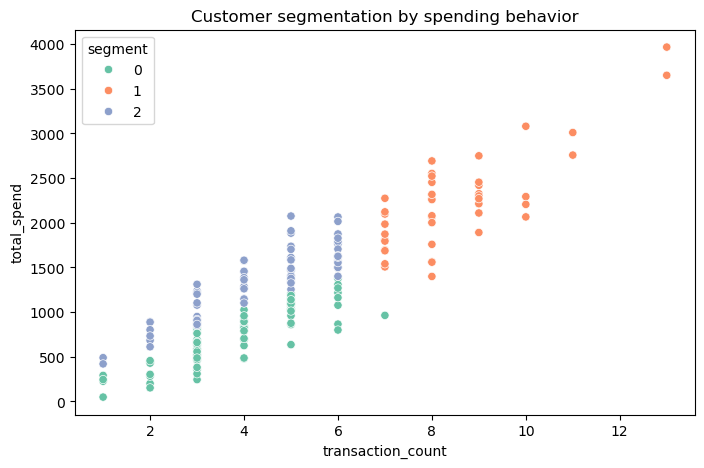

In [21]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=customer_summary,
    x="transaction_count",
    y="total_spend",
    hue="segment",
    palette="Set2"
)
plt.title("Customer segmentation by spending behavior")
plt.show()


# The next big step is Feature Engineering



## Step 1: Extract time features

##### I will create additional columns like day of week and month to understand temporal purchasing patterns.

#### Why this matters:
##### Time features help identify trends such as which days or months generate the most sales.


In [22]:
# Extract day of week and month
df['day_of_week'] = df['transaction_date'].dt.day_name()
df['month'] = df['transaction_date'].dt.month

# Quick preview
df.head()


,customer_id,amount,transaction_date,day_of_week,month
0,103,295.335040,2023-01-01,Sunday,1
1,180,284.406979,2023-01-02,Monday,1
2,93,192.492450,2023-01-03,Tuesday,1
3,15,172.036183,2023-01-04,Wednesday,1
4,107,450.325462,2023-01-05,Thursday,1


## Step 2: Aggregate customer behavior

##### I will summarize transactions per customer to create features for segmentation.

#### Why this matters:
##### Aggregating allows us to compare customers based on behavior rather than individual transactions.


In [23]:
customer_summary = df.groupby('customer_id').agg(
    total_spend=('amount', 'sum'),
    transaction_count=('amount', 'count'),
    avg_spend=('amount', 'mean'),
    first_purchase=('transaction_date', 'min'),
    last_purchase=('transaction_date', 'max')
).reset_index()

# Preview aggregated data
customer_summary.head()


,customer_id,total_spend,transaction_count,avg_spend,first_purchase,last_purchase
0,1,2452.515228,8,306.564404,2023-05-18,2025-08-08
1,2,1736.896618,5,347.379324,2023-01-20,2024-06-26
2,3,1773.132274,6,295.522046,2023-07-07,2025-08-27
3,4,836.761564,4,209.190391,2023-03-19,2025-04-08
4,5,1493.776680,6,248.962780,2023-04-28,2025-07-09


## Step 3: Calculate recency, frequency, monetary (rfm)

##### I did this becuase these features are widely used in retail analytics to segment customers by value.

#### Why this matters:

##### RFM features allow us to segment customers based on how recently, how often, and how much they purchase. Key for marketing strategy.


In [59]:
import pandas as pd
from datetime import datetime

# Ensure transaction_date is datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Reference date (today or last transaction +1)
reference_date = df['transaction_date'].max() + pd.Timedelta(days=1)

# Aggregate per customer
df_rfm = df.groupby('customer_id').agg(
    recency_days=('transaction_date', lambda x: (reference_date - x.max()).days),
    frequency=('transaction_date', 'count'),
    monetary=('amount', 'sum')
).reset_index()


In [ ]:
## Step 4: Encode categorical features

##### I need to convert text-based features (like day_of_week) into numeric form for clustering models.

#### Why this matters:

##### Many machine learning models require numeric inputs, so encoding is necessary.


In [30]:
import pandas as pd

# Define the days in order
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=days_order, ordered=True)

# One-hot encode without dropping the first day
df_encoded = pd.get_dummies(df, columns=['day_of_week'], drop_first=False)

df_encoded.head()


,customer_id,amount,transaction_date,month,day_of_week_Monday,day_of_week_Tuesday,day_of_week_Wednesday,day_of_week_Thursday,day_of_week_Friday,day_of_week_Saturday,day_of_week_Sunday
0,103,295.335040,2023-01-01,1,False,False,False,False,False,False,True
1,180,284.406979,2023-01-02,1,True,False,False,False,False,False,False
2,93,192.492450,2023-01-03,1,False,True,False,False,False,False,False
3,15,172.036183,2023-01-04,1,False,False,True,False,False,False,False
4,107,450.325462,2023-01-05,1,False,False,False,True,False,False,False


## Another big step is customer segmentation & visualization


### Description:

- Cluster customers using RFM features to identify segments.

- Visualize clusters with scatter plots for frequency vs monetary value.

- Export the cleaned and aggregated dataset for dashboard reporting.

#### Why this matters:

##### It helps UK retailers understand customer behavior, target high-value segments, and make data-driven marketing decisions.


## Step 1: Scale features

##### I have to scale numeric features (RFM: Recency, Frequency, Monetary) so clustering models treat each feature equally.

#### Why this matters:
##### Without scaling, features with larger numeric ranges (e.g., total spend) would dominate clustering results.


In [31]:
from sklearn.preprocessing import StandardScaler

# Select features for clustering
features = ['recency_days', 'frequency', 'monetary']

scaler = StandardScaler()
scaled_features = scaler.fit_transform(customer_summary[features])

# Check shape
scaled_features.shape


(198, 3)

## Apply KMeans clustering

#### Step 2: Customer segmentation with KMeans

##### I have to group customers into segments based on their purchasing behavior.

#### Why this matters:
##### Clustering allows retailers to target different customer groups with tailored marketing.

In [60]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select RFM features
rfm_features = df_rfm[['recency_days', 'frequency', 'monetary']]

# Scale features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df_rfm['cluster'] = kmeans.fit_predict(rfm_scaled) + 1  # cluster labels 1,2,3


C:\Users\ASUS-PC\OneDrive\Attachments\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [ ]:
## Analyze cluster characteristics

### Step 3: Understand segments

##### I have to summarize each cluster to interpret customer profiles.


In [33]:
cluster_summary = customer_summary.groupby('segment').agg(
    avg_recency=('recency_days', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    count=('customer_id', 'count')
).reset_index()

cluster_summary


,segment,avg_recency,avg_frequency,avg_monetary,count
0,0,542.000000,3.156250,753.194735,32
1,1,143.444444,4.111111,1015.590080,108
2,2,106.189655,7.844828,2117.713333,58


## Step 4: Visualize customer segments

##### I have to create a scatter plot to show clusters and understand relationships between frequency and spend.

#### Why this matters:
##### Visualizations make it easier for stakeholders to understand segments at a glance.


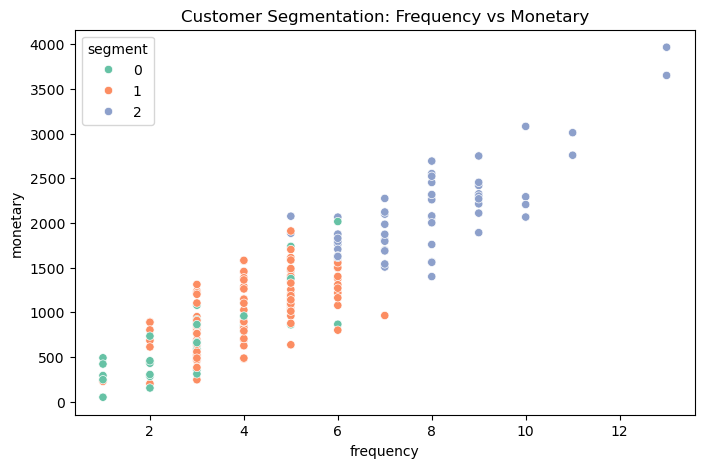

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=customer_summary,
    x='frequency',
    y='monetary',
    hue='segment',
    palette='Set2'
)
plt.title("Customer Segmentation: Frequency vs Monetary")
plt.show()


## Step 5: Export processed data for Power BI visualization

##### I  saved the cleaned, aggregated, and segmented dataset so Power BI can create interactive dashboards. 
##### This ensures stakeholders can easily explore insights without rerunning Python code.


In [78]:
import os

# Full path to your data folder in the project
project_data_path = r"C:\Users\ASUS-PC\OneDrive\Desktop\retail-sales-analytics\data"

# Create folder if it doesn't exist
os.makedirs(project_data_path, exist_ok=True)

# Save CSV there
customer_summary.to_csv(os.path.join(project_data_path, "customer_segments.csv"), index=False)

print(f"Customer segments dataset saved to: {project_data_path}")


Customer segments dataset saved to: C:\Users\ASUS-PC\OneDrive\Desktop\retail-sales-analytics\data


## Note:

###### Why MySQL is mentioned but not used directly in this project

I list MySQL as one of the tools because in real UK retail environments, transaction data is often stored in relational databases. 

###### In this project:

- We **do not create actual databases or tables**, and we **do not run SQL queries**.  
- Instead, we simulate the workflow using **synthetic CSV data** to demonstrate the same analysis and customer segmentation steps.  
- The workflow is fully compatible with MySQL, so in a production environment, the same code could pull data directly from a database.  

**Why this matters:**  
Including MySQL in the tools shows that I understand **real-world data pipelines**, while keeping the project **reproducible and privacy-compliant**.
